In [1]:
import tango
import numpy as np
import matplotlib.pyplot as plt
%matplotlib ipympl
import json
import pyTEMlib
import pyTEMlib.probe_tools as pt
import pyTEMlib.image_tools as it

In [2]:
# uv run python -m tango.test_context asyncroscopy.hardware.CORRECTOR.CORRECTOR --host 127.0.0.1 --port 8890

## 1. Connect to devices

In [2]:
corrector_proxy = tango.DeviceProxy("tango://127.0.0.1:8890/test/nodb/corrector#dbase=no")
corrector_proxy.set_timeout_millis(120_000)
print('Corrector state     :', corrector_proxy.state())

Corrector state     : ON


In [3]:
print('\n--- corrector commands ---')
for cmd in corrector_proxy.get_command_list():
    print(f'  {cmd}')


--- corrector commands ---
  Init
  State
  Status
  acquire_tableau
  correct_aberration
  get_info
  measure_c1a1
  reconnect


Acceleration voltage 60.0kV  => wavelength 4.87pm
0.003


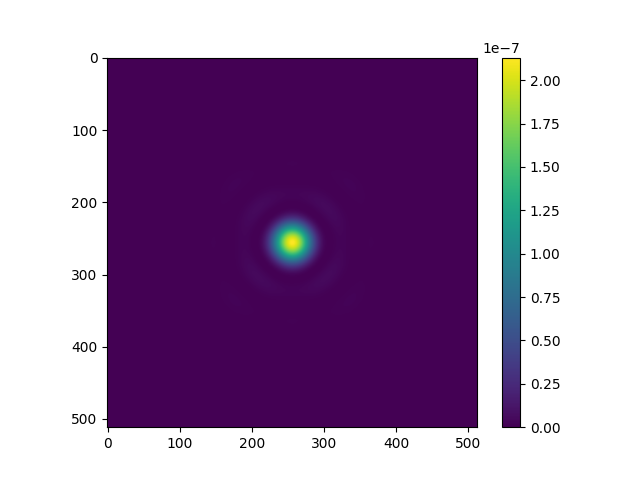

In [4]:
ab_msg = corrector_proxy.acquire_tableau('Enhanced 40')
ab = json.loads(ab_msg)['result']['aberrations']

ab['acceleration_voltage'] = 60e3 # eV
ab['FOV'] = 100 /10 # nm
ab['convergence_angle'] = 3 # mrad
ab['wavelength'] = it.get_wavelength(ab['acceleration_voltage'])

probe, A_k, chi  = pt.get_probe(ab, 512, 512, verbose= True)

plt.figure()
plt.imshow(probe)
plt.colorbar()

### GUI

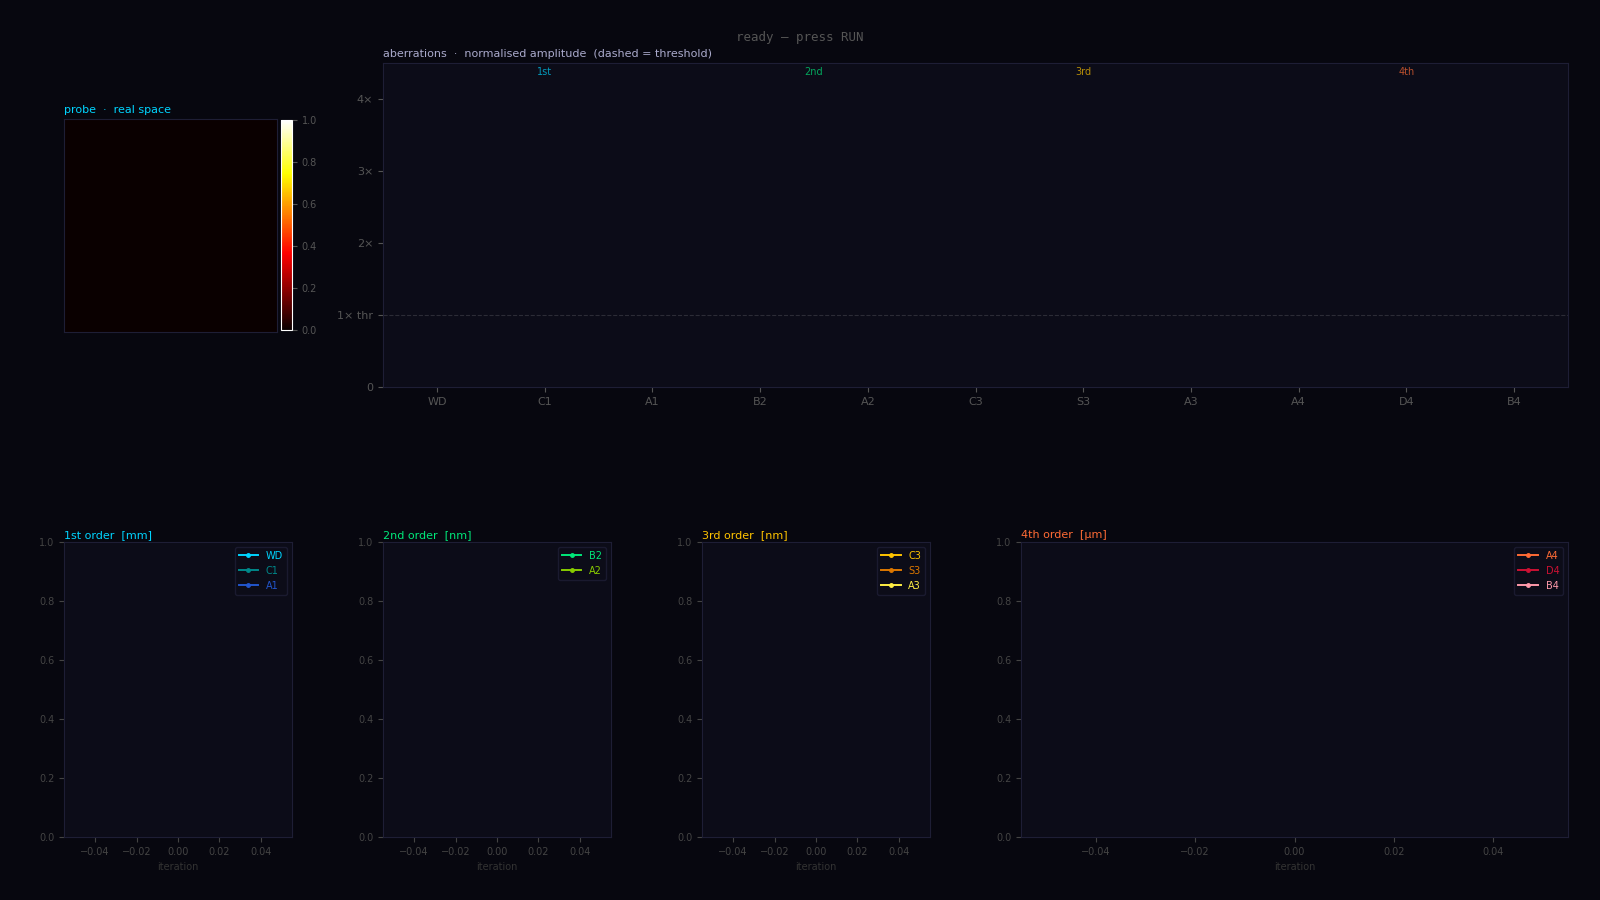

In [4]:
"""
Aberration Correction GUI
=========================
Paste into a Jupyter notebook cell.  Requires in the cell above:

    %matplotlib widget

Assumes `corrector_proxy` is a Tango DeviceProxy already in scope.

Workflow (mirrors the original nested-loop design):

    outer loop — repeat until 3rd+4th order clean:
        inner loop — repeat Fast 1 until 1st+2nd order clean
        one Enhanced 40 measurement
        correct 3rd order  (if anything bad)
        else correct 4th order

Probe panel:
    Swap the two commented lines in update_probe() to use real pt.get_probe().
"""

import json
import threading

import ipywidgets as widgets
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

# ── Aberration configuration ──────────────────────────────────────────────────

first_order  = ['WD', 'C1', 'A1']
second_order = ['B2', 'A2']
third_order  = ['C3', 'S3', 'A3']
fourth_order = ['A4', 'D4', 'B4']
all_keys     = first_order + second_order + third_order + fourth_order

# WD, C1, C3 are scalar — Tango server expects "KEY x" (one float).
# All others are 2-component — expects "KEY x y".
SCALAR_KEYS = {'WD', 'C1', 'C3'}

fourth_order_factor = 0.50

thresholds = {
    'WD': 5e-3,   'C1': 5e-9,   'A1': 5e-9,
    'B2': 50e-9,  'A2': 100e-9,
    'C3': 1e-6, 'S3': 0.7e-6, 'A3': 1e-6,
    'A4': 10e-6,   'D4': 4e-6,   'B4': 10e-6,
}

display_scale = {
    'WD': 1e3,  'C1': 1e9,  'A1': 1e9,
    'B2': 1e9,  'A2': 1e9,
    'C3': 1e9,  'S3': 1e9,  'A3': 1e9,
    'A4': 1e6,  'D4': 1e6,  'B4': 1e6,
}
display_units = {
    'WD': 'mm', 'C1': 'nm', 'A1': 'nm',
    'B2': 'nm', 'A2': 'nm',
    'C3': 'nm', 'S3': 'nm', 'A3': 'nm',
    'A4': 'µm', 'D4': 'µm', 'B4': 'µm',
}

order_groups = {
    '1st': {'keys': first_order,  'color': '#00d4ff'},
    '2nd': {'keys': second_order, 'color': '#00e87a'},
    '3rd': {'keys': third_order,  'color': '#ffc400'},
    '4th': {'keys': fourth_order, 'color': '#ff6b35'},
}

key_colors = {
    # 1st order: bright cyan → teal → steel blue
    'WD': '#00d4ff', 'C1': '#00888a', 'A1': '#2255cc',
    # 2nd order: bright green → olive
    'B2': '#00e87a', 'A2': '#88cc00',
    # 3rd order: bright yellow → amber → orange-yellow
    'C3': '#ffc400', 'S3': '#dd7700', 'A3': '#ffee44',
    # 4th order: bright orange → crimson → salmon
    'A4': '#ff6b35', 'D4': '#cc1133', 'B4': '#ff99aa',
}

# ── Hardware interface ────────────────────────────────────────────────────────

def norm(v):
    return float(np.linalg.norm(v))


def acquire(tableau_type):
    """
    Run a tableau and return the aberrations dict.
    tableau_type: e.g. 'Fast 1', 'Enhanced 40'
    """
    raw = corrector_proxy.acquire_tableau(tableau_type)
    return json.loads(raw)['result']['aberrations']


def correct(key, v):
    """
    Send a correction via the Tango proxy.
    Scalar keys (WD, C1, C3) → "KEY x"
    Vector keys              → "KEY x y"
    """
    v = list(v)
    if key in SCALAR_KEYS:
        corrector_proxy.correct_aberration(f"{key} {v[0]}")
    else:
        corrector_proxy.correct_aberration(f"{key} {v[0]} {v[1]}")


def correct_12(ab):
    """Correct 1st and 2nd order. Returns list of corrected keys."""
    corrected = []
    for key in first_order + second_order:
        if norm(ab.get(key, [0, 0])) > thresholds[key]:
            correct(key, ab[key])
            corrected.append(key)
    return corrected


def correct_3rd(ab):
    """
    Correct 3rd order. C3 gates S3/A3 — if C3 is bad, skip S3/A3.
    Returns list of corrected keys.
    """
    corrected = []
    if norm(ab.get('C3', [0, 0])) > thresholds['C3']:
        correct('C3', ab['C3'])
        corrected.append('C3')
    else:
        for key in ['S3', 'A3']:
            if norm(ab.get(key, [0, 0])) > thresholds[key]:
                correct(key, ab[key])
                corrected.append(key)
    return corrected


def correct_4th(ab, factor):
    """Correct 4th order with partial factor. Returns list of corrected keys."""
    corrected = []
    for key in fourth_order:
        if norm(ab.get(key, [0, 0])) > thresholds[key]:
            correct(key, [v * factor for v in ab[key]])
            corrected.append(key)
    return corrected

# ── Figure layout ─────────────────────────────────────────────────────────────

plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 9), facecolor='#07070f')
try:
    fig.canvas.header_visible = False
except AttributeError:
    pass

gs = gridspec.GridSpec(
    2, 5,
    figure=fig,
    left=0.04, right=0.98, top=0.93, bottom=0.07,
    wspace=0.40, hspace=0.50,
    width_ratios=[1, 1, 1, 1, 1],
    height_ratios=[1.1, 1],
)

ax_probe = fig.add_subplot(gs[0, 0])
ax_bars  = fig.add_subplot(gs[0, 1:])
ax_hist  = {
    '1st': fig.add_subplot(gs[1, 0]),
    '2nd': fig.add_subplot(gs[1, 1]),
    '3rd': fig.add_subplot(gs[1, 2]),
    '4th': fig.add_subplot(gs[1, 3:]),
}

for ax in [ax_probe, ax_bars] + list(ax_hist.values()):
    ax.set_facecolor('#0c0c18')
    for sp in ax.spines.values():
        sp.set_color('#1e1e35')

# ── Probe panel ───────────────────────────────────────────────────────────────

ax_probe.set_title('probe  ·  real space', fontsize=8, color='#00d4ff', pad=4, loc='left')
ax_probe.set_xticks([])
ax_probe.set_yticks([])
probe_im = ax_probe.imshow(
    np.zeros((64, 64)), cmap='hot', vmin=0, vmax=1,
    interpolation='nearest', origin='lower',
)
cb = fig.colorbar(probe_im, ax=ax_probe, fraction=0.046, pad=0.02)
cb.ax.tick_params(labelsize=7, colors='#555')

# ── Bar panel ─────────────────────────────────────────────────────────────────

ax_bars.set_title(
    'aberrations  ·  normalised amplitude  (dashed = threshold)',
    fontsize=8, color='#aaaacc', pad=4, loc='left',
)
ax_bars.set_xlim(-0.5, len(all_keys) - 0.5)
ax_bars.set_xticks(range(len(all_keys)))
ax_bars.set_xticklabels(all_keys, fontsize=8)
ax_bars.set_ylim(0, 4.5)
ax_bars.set_yticks([0, 1, 2, 3, 4])
ax_bars.set_yticklabels(['0', '1× thr', '2×', '3×', '4×'], fontsize=7, color='#555')
ax_bars.tick_params(colors='#555', labelsize=8)
ax_bars.axhline(1.0, color='#ffffff22', linewidth=0.8, linestyle='--')

bar_rects = ax_bars.bar(
    range(len(all_keys)),
    [0] * len(all_keys),
    color=[key_colors[k] for k in all_keys],
    alpha=0.75,
    edgecolor='none',
    width=0.6,
)

for ord_name, grp in order_groups.items():
    idx = [all_keys.index(k) for k in grp['keys']]
    ax_bars.text(
        np.mean(idx), 4.3, ord_name,
        ha='center', va='bottom', fontsize=7,
        color=grp['color'], alpha=0.7,
    )

# ── History panels ────────────────────────────────────────────────────────────

history_lines = {}
for ord_name, grp in order_groups.items():
    ax   = ax_hist[ord_name]
    key0 = grp['keys'][0]
    ax.set_title(
        f"{ord_name} order  [{display_units[key0]}]",
        fontsize=8, color=grp['color'], pad=3, loc='left',
    )
    ax.tick_params(colors='#444', labelsize=7)
    ax.set_xlabel('iteration', fontsize=7, color='#333')
    ax.set_ylim(0, 1)

    history_lines[ord_name] = {}
    for k in grp['keys']:
        ax.axhline(
            thresholds[k] * display_scale[k],
            color=key_colors[k], linewidth=0.6, linestyle=':', alpha=0.4,
        )
        line, = ax.plot(
            [], [], color=key_colors[k],
            linewidth=1.4, label=k,
            marker='o', markersize=2.5,
        )
        history_lines[ord_name][k] = line

    leg = ax.legend(fontsize=7, loc='upper right',
                    facecolor='#0c0c18', edgecolor='#1e1e35')
    for text, k in zip(leg.get_texts(), grp['keys']):
        text.set_color(key_colors[k])

# ── Status text ───────────────────────────────────────────────────────────────

status_text = fig.text(
    0.5, 0.965, 'ready — press RUN',
    ha='center', va='top', fontsize=9,
    color='#555', fontfamily='monospace',
)

# ── Runtime state ─────────────────────────────────────────────────────────────

# history indexed by measurement number (each acquire() call = one entry)
history     = {k: [] for k in all_keys}
_stop_flag  = threading.Event()

# ── Live update functions ─────────────────────────────────────────────────────

def update_probe(ab):
    """
    Simulated probe.  Replace block with:
        probe, _, _ = pt.get_probe(ab, 512, 512)
        probe_im.set_data(np.abs(probe) ** 2)
        probe_im.autoscale()
    """
    N      = 64
    C1_nm  = norm(ab.get('C1', [0, 0])) * 1e9
    A1_v   = ab.get('A1', [0, 0])
    A1_nm  = norm(A1_v) * 1e9
    A1_ang = np.arctan2(A1_v[1], A1_v[0])
    C3_nm  = norm(ab.get('C3', [0, 0])) * 1e9
    sigma   = 3.5 * (1 + C1_nm / 5 * 0.5 + C3_nm / 350 * 0.3)
    astig   = min(A1_nm / 5 * 0.6, 2.0)
    y, x    = np.ogrid[:N, :N]
    dx, dy  = x - N / 2, y - N / 2
    phi     = np.arctan2(dy, dx)
    r       = np.hypot(dx, dy)
    sig_eff = sigma * (1 + astig * np.cos(2 * (phi - A1_ang)) * 0.25)
    probe   = np.exp(-r ** 2 / (2 * sig_eff ** 2))
    probe  /= probe.max()
    probe_im.set_data(probe)
    probe_im.set_clim(0, 1)


def record_and_redraw(ab, measured_keys=None):
    """
    Append measurement to history.
    measured_keys: list of keys actually measured in this tableau.
                   Keys NOT in this list repeat their last known value
                   rather than being recorded as 0.
    If measured_keys is None, all keys are treated as measured.
    """
    if measured_keys is None:
        measured_keys = all_keys
    for k in all_keys:
        if k in measured_keys:
            history[k].append(norm(ab.get(k, [0, 0])))
        else:
            # repeat last known value (or 0 if no history yet)
            last = history[k][-1] if history[k] else 0.0
            history[k].append(last)
    update_bars(ab)
    update_probe(ab)
    update_history()
    redraw()


def update_bars(ab):
    for i, k in enumerate(all_keys):
        amp        = norm(ab.get(k, [0, 0]))
        normalised = amp / thresholds[k]
        bar_rects[i].set_height(min(normalised, 4.5))
        bar_rects[i].set_alpha(0.9 if amp > thresholds[k] else 0.30)


def update_history():
    n = len(history[all_keys[0]])
    if n == 0:
        return
    iters = list(range(1, n + 1))
    for ord_name, grp in order_groups.items():
        ax       = ax_hist[ord_name]
        all_vals = []
        for k in grp['keys']:
            y = [v * display_scale[k] for v in history[k]]
            history_lines[ord_name][k].set_data(iters, y)
            all_vals.extend(y)
        ax.set_xlim(1, max(n, 2))
        if all_vals:
            ymax   = max(all_vals) * 1.25
            yfloor = thresholds[grp['keys'][0]] * display_scale[grp['keys'][0]] * 1.5
            ax.set_ylim(0, max(ymax, yfloor))


def redraw():
    fig.canvas.draw_idle()

# ── Correction loop ───────────────────────────────────────────────────────────

def run_correction(max_outer, fourth_factor, log_out):
    """
    Mirrors the original workflow:

        outer loop (Enhanced):
            inner loop (Fast) until 1st+2nd clean
            Enhanced 40 measurement
            correct 3rd  →  if anything corrected, next outer iteration
            else correct 4th  →  if anything corrected, next outer iteration
            else done
    """
    _stop_flag.clear()

    with log_out:
        log_out.clear_output(wait=True)
        print('─' * 52)
        print(f'  Aberration correction  —  max {max_outer} outer iterations')
        print('─' * 52)

    def stopped():
        if _stop_flag.is_set():
            with log_out:
                print('\n  ⚠  Stopped by user.')
            status_text.set_text('stopped')
            status_text.set_color('#ff4444')
            redraw()
            return True
        return False

    def safe_acquire(tableau_type, label):
        try:
            return acquire(tableau_type)
        except Exception as exc:
            with log_out:
                print(f'  ERROR acquiring {label}: {exc}')
            status_text.set_text('error')
            status_text.set_color('#ff4444')
            redraw()
            return None

    # ── outer loop ────────────────────────────────────────────────────────────
    for outer in range(max_outer):
        if stopped(): return

        with log_out:
            print(f'\n━━  Outer iteration {outer + 1}/{max_outer}  ━━')

        # ── inner loop: Fast 1 until 1st+2nd clean ────────────────────────
        inner = 0
        while True:
            if stopped(): return
            inner += 1
            with log_out:
                print(f'  [Fast]  inner iter {inner}')
            status_text.set_text(f'outer {outer+1}  ·  Fast iter {inner}')
            status_text.set_color('#00d4ff')
            redraw()

            ab = safe_acquire('Fast 10', 'Fast 10')
            if ab is None: return

            record_and_redraw(ab, measured_keys=first_order + second_order)

            corrected_12 = correct_12(ab)
            with log_out:
                tag = ', '.join(corrected_12) if corrected_12 else '(none — 1st/2nd clean)'
                print(f'    corrected: {tag}')

            #if not corrected_12:
            break   # 1st+2nd order converged → move to Enhanced

        # ── Enhanced 40 measurement + 3rd/4th correction ──────────────────
        if stopped(): return
        with log_out:
            print(f'  [Enhanced]')
        status_text.set_text(f'outer {outer+1}  ·  Enhanced 40')
        status_text.set_color('#ffc400')
        redraw()

        ab_enh = safe_acquire('Enhanced 40', 'Enhanced 40')
        if ab_enh is None: return

        record_and_redraw(ab_enh, measured_keys=all_keys)

        corrected_3 = correct_3rd(ab_enh)
        if corrected_3:
            with log_out:
                print(f'    3rd order corrected: {corrected_3}')
            # go back to top of outer loop (re-do inner Fast loop)
            continue

        corrected_4 = correct_4th(ab_enh, fourth_factor)
        if corrected_4:
            with log_out:
                print(f'    4th order corrected: {corrected_4}')
            # go back to top of outer loop
            continue

        # Nothing corrected in 3rd or 4th — fully converged
        with log_out:
            print(f'\n  ✦  Converged after outer iteration {outer + 1}.')
        status_text.set_text(f'converged — outer iter {outer + 1}')
        status_text.set_color('#00e87a')
        redraw()
        return

    with log_out:
        print(f'\n  Done — {max_outer} outer iterations complete.')
    status_text.set_text('done')
    status_text.set_color('#00e87a')
    redraw()

# ── Widget controls ───────────────────────────────────────────────────────────

w_max_iter = widgets.BoundedIntText(
    value=5, min=1, max=20, step=1,
    description='Max outer:',
    style={'description_width': '70px'},
    layout=widgets.Layout(width='160px'),
)
w_fourth_factor = widgets.BoundedFloatText(
    value=0.5, min=0.05, max=1.0, step=0.05,
    description='4th ×:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='150px'),
)
w_run = widgets.Button(
    description='▶  RUN',
    style={'button_color': '#001a20', 'font_weight': 'bold'},
    layout=widgets.Layout(width='100px', height='32px'),
)
w_stop = widgets.Button(
    description='■  STOP',
    button_style='danger',
    layout=widgets.Layout(width='100px', height='32px'),
)
log_out = widgets.Output(
    layout=widgets.Layout(
        width='100%', height='220px',
        overflow_y='auto',
        padding='8px 12px',
    )
)

log_panel = widgets.VBox(
    [
        widgets.HTML(value=(
            '<div style="'
            'font-family:monospace;'
            'font-size:10px;'
            'letter-spacing:4px;'
            'color:#334;'
            'background:#0a0a14;'
            'padding:5px 12px 4px 12px;'
            'border-bottom:1px solid #1a1a30;'
            '">OUTPUT LOG</div>'
        )),
        log_out,
    ],
    layout=widgets.Layout(border='1px solid #1a1a30', width='100%'),
)

_thread = None

def on_run(_):
    global _thread, history
    history = {k: [] for k in all_keys}
    for ord_name, grp in order_groups.items():
        for k in grp['keys']:
            history_lines[ord_name][k].set_data([], [])
    _thread = threading.Thread(
        target=run_correction,
        args=(w_max_iter.value, w_fourth_factor.value, log_out),
        daemon=True,
    )
    _thread.start()

def on_stop(_):
    _stop_flag.set()

w_run.on_click(on_run)
w_stop.on_click(on_stop)

controls = widgets.HBox(
    [w_max_iter, w_fourth_factor, w_run, w_stop],
    layout=widgets.Layout(gap='12px', align_items='center', padding='6px 0'),
)

display(widgets.VBox([controls, log_panel], layout=widgets.Layout(gap='6px')))
plt.show()